0. Przypomnij sobie, albo posłuchaj przypomnienia na wykładzie, czym jest rozkład normalny.

1. Wygeneruj milion liczb z rozkładu normalnego o średniej 0 i wariancji 1 używając funkcji
numpy.random.randn(...). Narysuj histogram takich danych.

2. Na histogramie wygenerowanych danych narysuj funkcję gęstości rozkładu prawdopodobień-
stwa. Porównaj histogram z funkcją gęstości.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
mu, sigma = 0, 1

data = mu + sigma * np.random.randn(10**6)

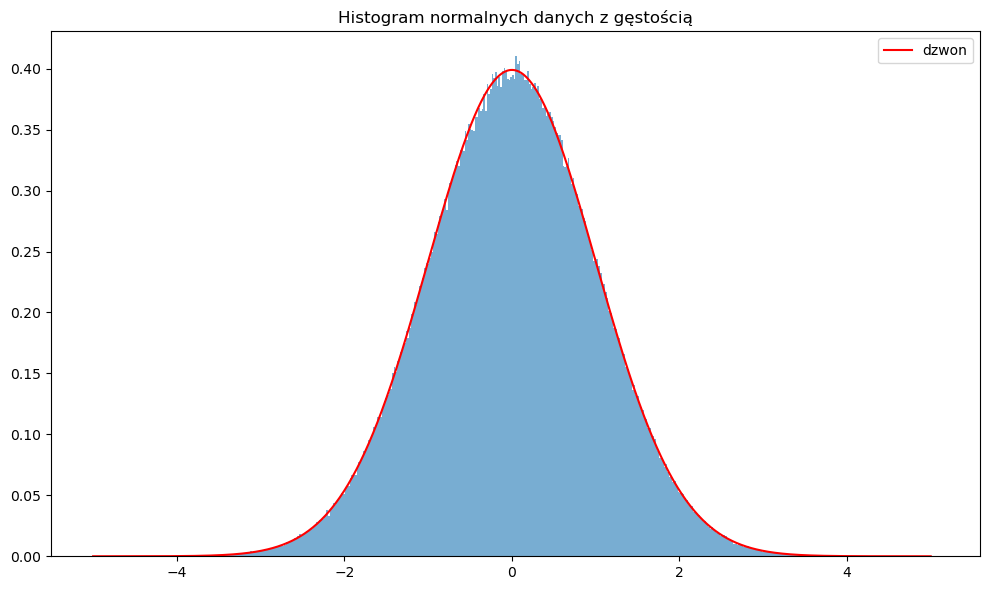

In [3]:
plt.figure(figsize=(10, 6))

x = np.linspace(-5, 5, 1000)
pdf = (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-(x-mu)**2 / (2*sigma**2))

# Histogram z normalizacją do gęstości
plt.hist(data, bins=500, alpha=0.6, density=True) 
# density=True normalizuje histogram, tzn nie liczy ilości próbek w binie, tylko gęstość prawdopodobieństwa
# bez tego rysunek byłby bardzo wysoki, bo mamy milion próbek a gęstość przecież jest mocniej ograniczona

plt.plot(x, pdf, color='red', label='dzwon')
plt.legend()
plt.title("Histogram normalnych danych z gęstością")
plt.tight_layout()
plt.show()


In [4]:
column_names = ["sepal_length", "sepal_width", "petal_length", "petal_width", "class"]
iris = pd.read_csv("../Zad1/iris.data", header=None, names=column_names)

In [5]:
n = len(iris)

sigma = 0.25

sepal_length_error = np.random.randn(n) * sigma
sepal_width_error = np.random.randn(n) * sigma

data = iris.copy()
data['sepal_length'] += sepal_length_error
data['sepal_width'] += sepal_width_error

Skopiowane z zad1.3

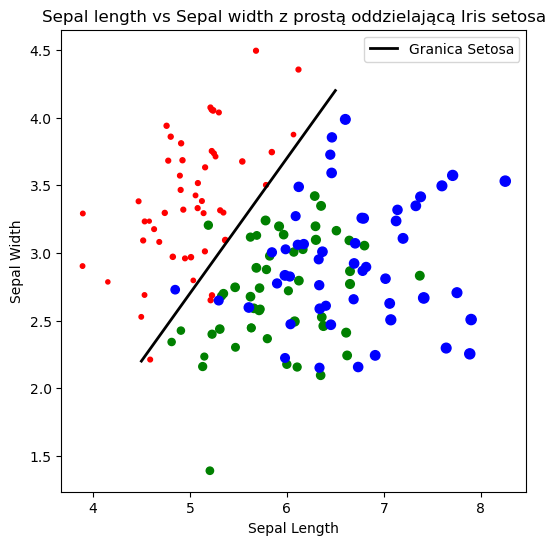

In [6]:
colors = {'Iris-setosa': 'red', 'Iris-versicolor': 'green', 'Iris-virginica': 'blue'} # mapa kolorów dla klas

plt.figure(figsize=(6, 6))
plt.scatter(data["sepal_length"], data["sepal_width"], color=data["class"].map(colors), s=data["petal_length"]*8)

x_values = np.linspace(4.5, 6.5, 100)
y_values = 2.2 + (x_values - 4.5) * 1 

# Rysujemy prostą
plt.plot(x_values, y_values, color="black", linewidth=2, label="Granica Setosa")

plt.title("Sepal length vs Sepal width z prostą oddzielającą Iris setosa")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend()
plt.show()

Nie działa tak dobrze, a może trochę zmniejszymy wariancję?

In [7]:
n = len(iris)

sigma = 0.1

sepal_length_error = np.random.randn(n) * sigma
sepal_width_error = np.random.randn(n) * sigma

data = iris.copy()
data['sepal_length'] += sepal_length_error
data['sepal_width'] += sepal_width_error

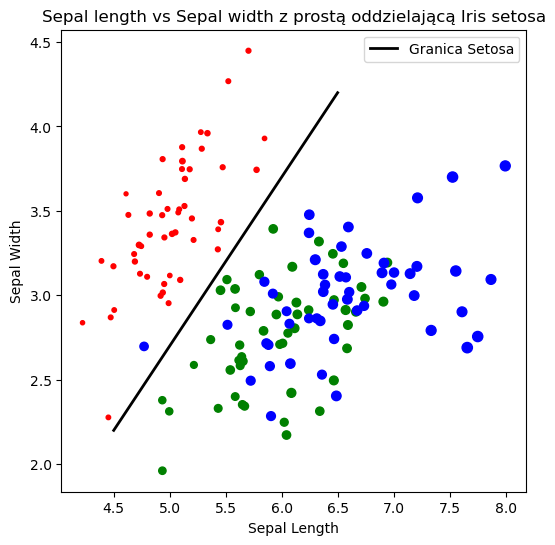

In [8]:
colors = {'Iris-setosa': 'red', 'Iris-versicolor': 'green', 'Iris-virginica': 'blue'} # mapa kolorów dla klas

plt.figure(figsize=(6, 6))
plt.scatter(data["sepal_length"], data["sepal_width"], color=data["class"].map(colors), s=data["petal_length"]*8)

x_values = np.linspace(4.5, 6.5, 100)
y_values = 2.2 + (x_values - 4.5) * 1 

# Rysujemy prostą
plt.plot(x_values, y_values, color="black", linewidth=2, label="Granica Setosa")

plt.title("Sepal length vs Sepal width z prostą oddzielającą Iris setosa")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend()
plt.show()

Lepiej. Ale i tak cięzko o lepszą prostą